# Lecture 2: Statistical Inference
**BITE 485 | Tharaka University**

---

## Learning Outcomes
1. Compute and interpret descriptive statistics
2. Visualise and understand probability distributions
3. Apply the Central Limit Theorem
4. Conduct hypothesis tests and interpret p-values
5. Construct confidence intervals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
print('Ready.')

Ready.


## 2.1 Descriptive Statistics

We simulate a dataset of 500 mobile money transactions (values in KES).

In [2]:
np.random.seed(42)
# Simulate right-skewed transaction data (most small, few large)
transactions = np.random.exponential(scale=500, size=500) + np.random.normal(0, 50, 500)
transactions = np.abs(transactions)

df = pd.DataFrame({'amount_kes': transactions})

print('--- Descriptive Statistics ---')
print(f'Mean:              KES {df.amount_kes.mean():.2f}')
print(f'Median:            KES {df.amount_kes.median():.2f}')
print(f'Std Dev:           KES {df.amount_kes.std():.2f}')
print(f'Min:               KES {df.amount_kes.min():.2f}')
print(f'Max:               KES {df.amount_kes.max():.2f}')
print(f'25th Percentile:   KES {df.amount_kes.quantile(0.25):.2f}')
print(f'75th Percentile:   KES {df.amount_kes.quantile(0.75):.2f}')
print(f'IQR:               KES {df.amount_kes.quantile(0.75) - df.amount_kes.quantile(0.25):.2f}')
print(f'Skewness:          {df.amount_kes.skew():.3f}')

--- Descriptive Statistics ---
Mean:              KES 507.00
Median:            KES 358.13
Std Dev:           KES 486.13
Min:               KES 1.45
Max:               KES 2402.63
25th Percentile:   KES 133.16
75th Percentile:   KES 718.17
IQR:               KES 585.01
Skewness:          1.428


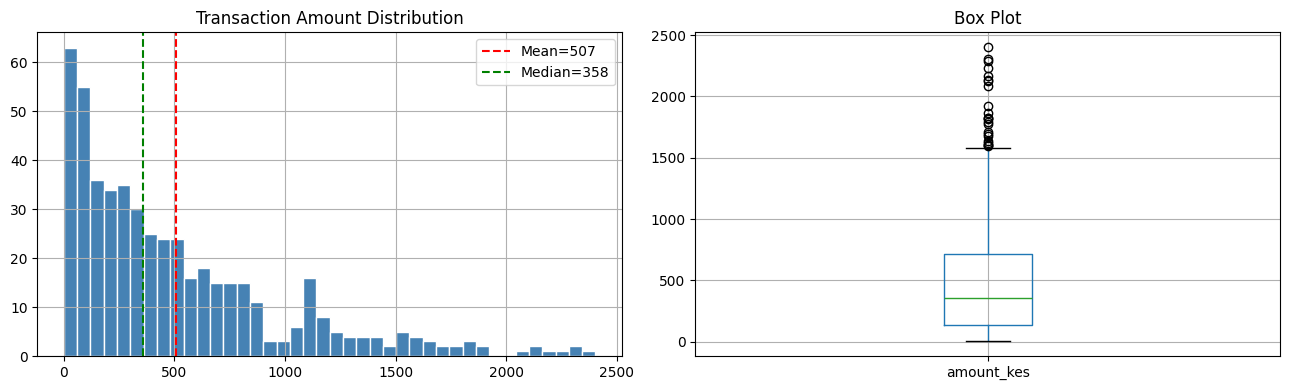

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['amount_kes'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(df.amount_kes.mean(), color='red', linestyle='--', label=f'Mean={df.amount_kes.mean():.0f}')
axes[0].axvline(df.amount_kes.median(), color='green', linestyle='--', label=f'Median={df.amount_kes.median():.0f}')
axes[0].set_title('Transaction Amount Distribution')
axes[0].legend()
df.boxplot(column='amount_kes', ax=axes[1])
axes[1].set_title('Box Plot')
plt.tight_layout()
plt.show()

## 2.2 The Central Limit Theorem in Action

No matter the shape of the population, the distribution of sample means approaches normal as n increases.

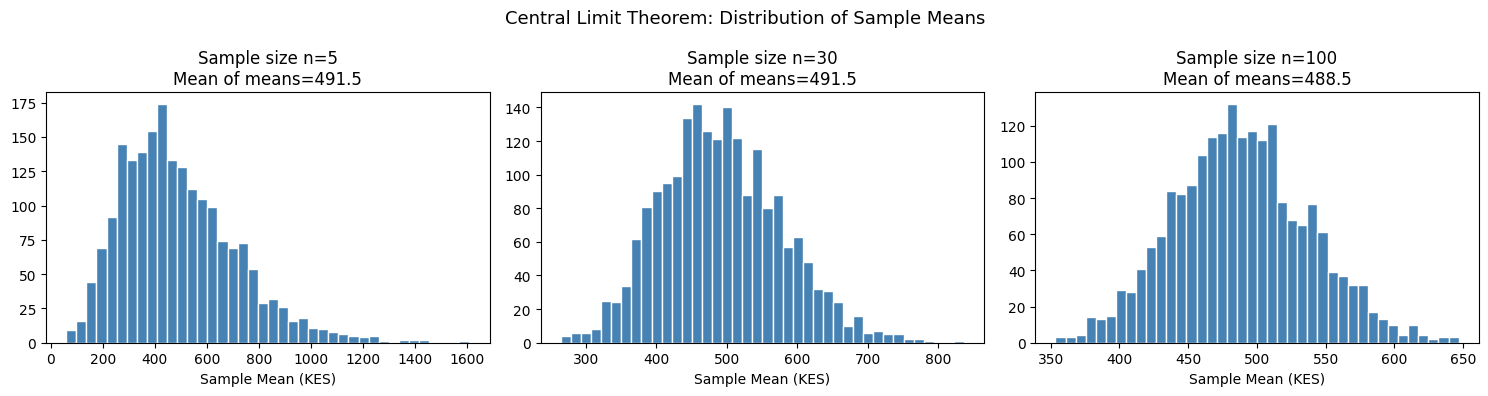

Notice: as n increases, the distribution of sample means becomes more normal.


In [4]:
np.random.seed(42)
population = np.random.exponential(scale=500, size=10000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, n in enumerate([5, 30, 100]):
    sample_means = [np.mean(np.random.choice(population, n)) for _ in range(2000)]
    axes[i].hist(sample_means, bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Sample size n={n}\nMean of means={np.mean(sample_means):.1f}')
    axes[i].set_xlabel('Sample Mean (KES)')
plt.suptitle('Central Limit Theorem: Distribution of Sample Means', fontsize=13)
plt.tight_layout()
plt.show()
print('Notice: as n increases, the distribution of sample means becomes more normal.')

## 2.3 Hypothesis Testing

**Scenario:** A mobile payments company claims its average transaction value is KES 500. A sample of 60 transactions has a mean of KES 470 and standard deviation KES 150. Is there evidence the true mean differs from KES 500?

In [5]:
# One-sample t-test
np.random.seed(7)
sample = np.random.normal(loc=470, scale=150, size=60)

t_stat, p_value = stats.ttest_1samp(sample, popmean=500)

print('=== One-Sample t-Test ===')
print(f'Null Hypothesis H0:  population mean = KES 500')
print(f'Alt  Hypothesis H1:  population mean ≠ KES 500 (two-tailed)')
print(f'\nSample mean:  KES {sample.mean():.2f}')
print(f'Sample std:   KES {sample.std():.2f}')
print(f't-statistic:  {t_stat:.4f}')
print(f'p-value:      {p_value:.4f}')
print(f'\nAlpha = 0.05')
if p_value < 0.05:
    print('Decision: REJECT H0. Evidence suggests the mean differs from KES 500.')
else:
    print('Decision: FAIL TO REJECT H0. Insufficient evidence to conclude the mean differs.')

=== One-Sample t-Test ===
Null Hypothesis H0:  population mean = KES 500
Alt  Hypothesis H1:  population mean ≠ KES 500 (two-tailed)

Sample mean:  KES 463.89
Sample std:   KES 158.39
t-statistic:  -1.7511
p-value:      0.0851

Alpha = 0.05
Decision: FAIL TO REJECT H0. Insufficient evidence to conclude the mean differs.


## 2.4 Two-Sample t-Test

**Scenario:** Did a UI redesign change average transaction values? Compare before vs after.

In [6]:
np.random.seed(42)
before = np.random.normal(loc=490, scale=120, size=80)
after  = np.random.normal(loc=530, scale=130, size=80)

t_stat, p_value = stats.ttest_ind(before, after)

print('=== Two-Sample t-Test ===')
print(f'Before redesign — mean: KES {before.mean():.2f}, std: {before.std():.2f}')
print(f'After  redesign — mean: KES {after.mean():.2f}, std: {after.std():.2f}')
print(f'Difference in means: KES {after.mean() - before.mean():.2f}')
print(f'\nt-statistic: {t_stat:.4f}')
print(f'p-value:     {p_value:.4f}')
if p_value < 0.05:
    print('Decision: REJECT H0. The redesign produced a statistically significant change.')
else:
    print('Decision: FAIL TO REJECT H0. No significant change detected.')

=== Two-Sample t-Test ===
Before redesign — mean: KES 475.14, std: 114.18
After  redesign — mean: KES 528.52, std: 118.54
Difference in means: KES 53.38

t-statistic: -2.8829
p-value:     0.0045
Decision: REJECT H0. The redesign produced a statistically significant change.


## 2.5 Confidence Intervals

In [7]:
from scipy.stats import t as t_dist

n = len(sample)
mean = sample.mean()
se = sample.std(ddof=1) / np.sqrt(n)
critical = t_dist.ppf(0.975, df=n-1)

ci_low  = mean - critical * se
ci_high = mean + critical * se

print(f'Sample mean: KES {mean:.2f}')
print(f'Standard error: KES {se:.2f}')
print(f'95% Confidence Interval: (KES {ci_low:.2f},  KES {ci_high:.2f})')
print(f'\nInterpretation: We are 95% confident that the true population mean')
print(f'transaction value lies between KES {ci_low:.0f} and KES {ci_high:.0f}.')

Sample mean: KES 463.89
Standard error: KES 20.62
95% Confidence Interval: (KES 422.63,  KES 505.15)

Interpretation: We are 95% confident that the true population mean
transaction value lies between KES 423 and KES 505.


### Exercise

A bank samples 45 loan applications. The mean requested amount is KES 85,000 with a standard deviation of KES 22,000. The bank claims the average loan request is KES 90,000.

1. State H0 and H1.
2. Conduct a one-sample t-test.
3. Interpret the result at alpha = 0.05.
4. Construct a 95% confidence interval for the true mean.

In [8]:
# Work from the summary statistics given in the question.
# The raw sample is not provided, so the t statistic is computed manually.
n = 45
sample_mean = 85000
sample_std = 22000
hypothesized_mean = 90000

# State the hypotheses in plain language.
print('=== Hypothesis Test ===')
print('H0: The true mean loan request is KES 90,000.')
print('H1: The true mean loan request is not KES 90,000.')

# Compute the test statistic manually from the summary values.
se = sample_std / np.sqrt(n)
t_stat = (sample_mean - hypothesized_mean) / se
df = n - 1
p_value = 2 * stats.t.sf(abs(t_stat), df=df)

print()
print(f'Sample mean:       KES {sample_mean:,.2f}')
print(f'Sample std dev:    KES {sample_std:,.2f}')
print(f'Standard error:    KES {se:,.2f}')
print(f't-statistic:       {t_stat:.4f}')
print(f'p-value:           {p_value:.4f}')
print(f'Degrees of freedom: {df}')

alpha = 0.05
print()
print(f'Alpha = {alpha}')
if p_value < alpha:
    print('Decision: REJECT H0. The sample gives evidence that the true mean differs from KES 90,000.')
else:
    print('Decision: FAIL TO REJECT H0. The sample does not give enough evidence that the true mean differs from KES 90,000.')

# Build a 95% confidence interval for the true mean.
critical = stats.t.ppf(0.975, df=df)
ci_low = sample_mean - critical * se
ci_high = sample_mean + critical * se

print()
print('=== 95% Confidence Interval ===')
print(f'95% CI: (KES {ci_low:,.2f}, KES {ci_high:,.2f})')
print('Interpretation: We are 95% confident the true average loan request lies within this range.')


=== Hypothesis Test ===
H0: The true mean loan request is KES 90,000.
H1: The true mean loan request is not KES 90,000.

Sample mean:       KES 85,000.00
Sample std dev:    KES 22,000.00
Standard error:    KES 3,279.57
t-statistic:       -1.5246
p-value:           0.1345
Degrees of freedom: 44

Alpha = 0.05
Decision: FAIL TO REJECT H0. The sample does not give enough evidence that the true mean differs from KES 90,000.

=== 95% Confidence Interval ===
95% CI: (KES 78,390.47, KES 91,609.53)
Interpretation: We are 95% confident the true average loan request lies within this range.


---
*BITE 485 Data Science | Tharaka University | kevin.tuei@tharaka.ac.ke*